# Dollar Bar Dataset Builder

Downloads Binance Vision aggTrade ZIPs, converts them to dollar bars, engineers
microstructure features, and writes a Parquet file ready for ML prototyping.

**No database required.** ZIPs are cached locally in `data/zip_cache/` so
re-running the notebook is fast after the first download.

---
### Output columns
| Column | Description |
|---|---|
| `open/high/low/close` | OHLC prices |
| `volume`, `dollar_volume` | Total and dollar volume |
| `buy_volume`, `sell_volume` | Tick-rule classified volumes |
| `trade_count` | Trades per bar |
| `ofi` | Order Flow Imbalance ∈ [−1, 1] |
| `kyle_lambda` | Price impact per unit signed flow |
| `realized_vol` | √Σ(log return)² over bar trades |
| `duration_s` | Seconds to fill bar |
| `log_return` | log(close / prev_close) |
| `vpin_10`, `vpin_50` | Rolling VPIN over 10 / 50 bars |
| `dollar_vol_z` | Z-score of dollar_volume (rolling 50-bar window) |
| `ofi_lag1`, `ofi_lag2` | Lagged OFI |
| `kyle_lag1` | Lagged Kyle λ |
| `vol_lag1` | Lagged realized volatility |
| `ret_1b`, `ret_5b` | Forward log returns (target variables) |

In [1]:
# ── 0. Imports ──────────────────────────────────────────────────────────────
import sys
from pathlib import Path

ROOT = Path("__file__").resolve().parent.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import math
from concurrent.futures import ThreadPoolExecutor, as_completed
from datetime import date, timedelta

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.ingestion.historical import stream_trades, iter_dates, fetch_zip
from src.processing.bars import AccumulatorState, process_trade
from src.processing.threshold import calibrate

from src.features.bsadf import qadf

sns.set_theme(style="darkgrid")
print("Imports OK")

Imports OK


In [2]:
# ── 1. Parameters ────────────────────────────────────────────────────────────
SYMBOL              = "BTCUSDT"
TARGET_BARS_PER_DAY = 75
CALIB_DAYS          = 5       # days sampled to estimate the threshold
DOWNLOAD_WORKERS    = 8       # parallel download threads

END_DATE   = date.today() - timedelta(days=3)
START_DATE = END_DATE - timedelta(days=89)   # 90 days

CACHE_DIR = ROOT / "data" / "zip_cache"      # ZIPs saved here; delete to force re-download
OUT_PATH  = ROOT / "data" / "dollar_bars.parquet"

print(f"Symbol : {SYMBOL}")
print(f"Range  : {START_DATE} → {END_DATE}  ({(END_DATE - START_DATE).days + 1} days)")
print(f"Cache  : {CACHE_DIR}")
print(f"Output : {OUT_PATH}")

Symbol : BTCUSDT
Range  : 2026-01-17 → 2026-04-16  (90 days)
Cache  : C:\Users\Atlas\Documents\Proyectos\quant_binance\data\zip_cache
Output : C:\Users\Atlas\Documents\Proyectos\quant_binance\data\dollar_bars.parquet


In [3]:
# ── 2. Parallel download ─────────────────────────────────────────────────────
# Download all missing ZIPs in parallel before doing any processing.
# Already-cached files are skipped immediately (fetch_zip checks disk first).

all_dates = list(iter_dates(START_DATE, END_DATE))

missing = [
    day for day in all_dates
    if not (CACHE_DIR / f"{SYMBOL}-aggTrades-{day.isoformat()}.zip").exists()
]
print(f"{len(all_dates) - len(missing)} days already cached, {len(missing)} to download")

if missing:
    failed = []
    with ThreadPoolExecutor(max_workers=DOWNLOAD_WORKERS) as pool:
        futures = {pool.submit(fetch_zip, SYMBOL, day, CACHE_DIR): day for day in missing}
        for i, future in enumerate(as_completed(futures), 1):
            day = futures[future]
            try:
                future.result()
            except Exception as exc:
                failed.append((day, exc))
            if i % 10 == 0 or i == len(missing):
                print(f"  downloaded {i}/{len(missing)}")

    if failed:
        print(f"WARNING: {len(failed)} days failed: {[d for d, _ in failed]}")

print("Download complete.")

89 days already cached, 1 to download
  downloaded 1/1
Download complete.


In [4]:
# ── 3. Threshold calibration ─────────────────────────────────────────────────
# Sample CALIB_DAYS evenly across the range — reads from cache, no network call.

step        = max(1, len(all_dates) // CALIB_DAYS)
sample_days = all_dates[::step][:CALIB_DAYS]

print(f"Calibrating on {len(sample_days)} sample days: {sample_days}")

daily_dvs = []
for day in sample_days:
    dv = sum(float(t["price"]) * float(t["qty"]) for t in stream_trades(SYMBOL, day, cache_dir=CACHE_DIR))
    daily_dvs.append(dv)
    print(f"  {day}  ${dv:>20,.0f}")

mean_daily_dv = float(np.mean(daily_dvs))
THRESHOLD     = calibrate(mean_daily_dv, TARGET_BARS_PER_DAY)

print(f"\nMean daily DV : ${mean_daily_dv:>20,.0f}")
print(f"Bar threshold : ${THRESHOLD:>20,.0f}")

Calibrating on 5 sample days: [datetime.date(2026, 1, 17), datetime.date(2026, 2, 4), datetime.date(2026, 2, 22), datetime.date(2026, 3, 12), datetime.date(2026, 3, 30)]
  2026-01-17  $         408,161,942
  2026-02-04  $       2,852,834,632
  2026-02-22  $         553,613,336
  2026-03-12  $       1,540,745,225
  2026-03-30  $       1,234,617,691

Mean daily DV : $       1,317,994,565
Bar threshold : $          17,573,261


In [5]:
# ── 4. Ingestion loop ────────────────────────────────────────────────────────
# Sequential by design: AccumulatorState is stateful across days.
# All reads come from disk cache — typically 1-2 min for 90 days.

state = AccumulatorState(symbol=SYMBOL, threshold=THRESHOLD)
bars  = []

for i, day in enumerate(all_dates):
    day_count = 0
    for trade in stream_trades(SYMBOL, day, cache_dir=CACHE_DIR):
        bar = process_trade(state, trade)
        if bar:
            bars.append(bar)
            day_count += 1

    if (i + 1) % 10 == 0 or i == len(all_dates) - 1:
        print(f"  day {i+1:>3}/{len(all_dates)}  {day}  bars today={day_count:>4}  total={len(bars):>6}")

print(f"\nTotal bars collected: {len(bars)}")

  day  10/90  2026-01-26  bars today=  88  total=   660
  day  20/90  2026-02-05  bars today= 409  total=  2330
  day  30/90  2026-02-15  bars today=  88  total=  3574
  day  40/90  2026-02-25  bars today= 117  total=  4332
  day  50/90  2026-03-07  bars today=  49  total=  5312
  day  60/90  2026-03-17  bars today= 103  total=  6311
  day  70/90  2026-03-27  bars today= 109  total=  7138
  day  80/90  2026-04-06  bars today=  80  total=  7721
  day  90/90  2026-04-16  bars today=  73  total=  8478

Total bars collected: 8478


In [6]:
# ── Diagnostic: where is the time going in the ingestion loop? ───────────────
import time

sample_day = all_dates[0]

# 1. Disk read only
t0 = time.perf_counter()
raw = fetch_zip(SYMBOL, sample_day, cache_dir=CACHE_DIR)
t_fetch = time.perf_counter() - t0
print(f"fetch_zip  (disk read)      : {t_fetch*1000:>7.1f} ms   {len(raw)/1e6:.1f} MB")

# 2. Full stream_trades (decompress + CSV parse)
t0 = time.perf_counter()
trades = list(stream_trades(SYMBOL, sample_day, cache_dir=CACHE_DIR))
t_stream = time.perf_counter() - t0
print(f"stream_trades (decomp+CSV)  : {t_stream*1000:>7.1f} ms   {len(trades):,} rows")

# 3. process_trade loop only
t0 = time.perf_counter()
_state = AccumulatorState(symbol=SYMBOL, threshold=THRESHOLD)
for tr in trades:
    process_trade(_state, tr)
t_proc = time.perf_counter() - t0
print(f"process_trade loop          : {t_proc*1000:>7.1f} ms")

total = t_fetch + t_stream + t_proc
print(f"\nTotal for 1 day             : {total:.2f} s")
print(f"Projected for 90 days       : {total * 90 / 60:.1f} min")
print(f"\nBottleneck share:")
for label, t in [("fetch_zip", t_fetch), ("CSV parse", t_stream), ("process_trade", t_proc)]:
    print(f"  {label:<22} {t/total*100:>5.1f}%")

fetch_zip  (disk read)      :     1.2 ms   5.0 MB
stream_trades (decomp+CSV)  :   296.6 ms   322,673 rows
process_trade loop          :   825.2 ms

Total for 1 day             : 1.12 s
Projected for 90 days       : 1.7 min

Bottleneck share:
  fetch_zip                0.1%
  CSV parse               26.4%
  process_trade           73.5%


In [7]:
# ── 5. Build DataFrame ───────────────────────────────────────────────────────
df = pd.DataFrame(bars)

df["open_time"]  = pd.to_datetime(df["open_time"],  utc=True, format="ISO8601")
df["close_time"] = pd.to_datetime(df["close_time"], utc=True, format="ISO8601")
df = df.sort_values("open_time").reset_index(drop=True)

df.info()
df.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8478 entries, 0 to 8477
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype              
---  ------         --------------  -----              
 0   symbol         8478 non-null   object             
 1   open_time      8478 non-null   datetime64[ns, UTC]
 2   close_time     8478 non-null   datetime64[ns, UTC]
 3   open           8478 non-null   float64            
 4   high           8478 non-null   float64            
 5   low            8478 non-null   float64            
 6   close          8478 non-null   float64            
 7   volume         8478 non-null   float64            
 8   dollar_volume  8478 non-null   float64            
 9   buy_volume     8478 non-null   float64            
 10  sell_volume    8478 non-null   float64            
 11  trade_count    8478 non-null   int64              
 12  ofi            8478 non-null   float64            
 13  kyle_lambda    8478 non-null   float64          

,symbol,open_time,close_time,open,high,low,close,volume,dollar_volume,buy_volume,sell_volume,trade_count,ofi,kyle_lambda,realized_vol,duration_s
0,BTCUSDT,2026-01-17 00:00:00.251000+00:00,2026-01-17 01:29:07.829000+00:00,95550.94,95578.20,95433.94,95465.98,184.01238,1.757383e+07,84.27094,99.74144,18068,-0.084073,0.023147,0.000424,5347.578
1,BTCUSDT,2026-01-17 01:29:08.790000+00:00,2026-01-17 02:45:50.436000+00:00,95465.97,95493.25,95200.00,95309.91,184.39912,1.757860e+07,67.59854,116.80058,15722,-0.266824,0.040033,0.000391,4601.646
2,BTCUSDT,2026-01-17 02:45:50.437000+00:00,2026-01-17 04:22:50.378000+00:00,95309.91,95384.87,95260.64,95273.14,184.76405,1.761165e+07,85.80265,98.96140,15743,-0.071219,0.038242,0.000411,5819.941


In [8]:
# ── 6. Feature engineering ───────────────────────────────────────────────────

df["log_return"] = np.log(df["close"] / df["close"].shift(1))

imbalance = (df["buy_volume"] - df["sell_volume"]).abs() / (
    df["buy_volume"] + df["sell_volume"]
)
df["vpin_10"] = imbalance.rolling(10, min_periods=5).mean()
df["vpin_50"] = imbalance.rolling(50, min_periods=25).mean()

dv_roll = df["dollar_volume"].rolling(50, min_periods=10)
df["dollar_vol_z"] = (df["dollar_volume"] - dv_roll.mean()) / dv_roll.std()

for col, lags in [("ofi", [1, 2]), ("kyle_lambda", [1]), ("realized_vol", [1])]:
    for lag in lags:
        label = (
            f"ofi_lag{lag}" if col == "ofi"
            else f"kyle_lag{lag}" if col == "kyle_lambda"
            else f"vol_lag{lag}"
        )
        df[label] = df[col].shift(lag)

df["ret_1b"] = df["log_return"].shift(-1)
df["ret_5b"] = df["log_return"].rolling(5).sum().shift(-5)

new_cols = ["log_return", "vpin_10", "vpin_50", "dollar_vol_z",
            "ofi_lag1", "ofi_lag2", "kyle_lag1", "vol_lag1", "ret_1b", "ret_5b"]
print(df[new_cols].describe().T[["count", "mean", "std", "min", "max"]].to_string())

               count      mean       std           min       max
log_return    8477.0 -0.000028  0.002982 -1.352313e-02  0.013539
vpin_10       8474.0  0.204193  0.074538  5.000156e-02  0.619324
vpin_50       8454.0  0.204261  0.043930  9.930044e-02  0.445699
dollar_vol_z  8469.0 -0.000874  0.984948 -9.952686e-01  6.915605
ofi_lag1      8477.0 -0.031697  0.259667 -9.999227e-01  0.928857
ofi_lag2      8476.0 -0.031703  0.259681 -9.999227e-01  0.928857
kyle_lag1     8477.0  0.159150  0.257483  1.506274e-06  6.200460
vol_lag1      8477.0  0.001078  0.000952  3.828244e-07  0.019969
ret_1b        8477.0 -0.000028  0.002982 -1.352313e-02  0.013539
ret_5b        8473.0 -0.000141  0.006644 -2.716068e-02  0.032170


In [9]:
# ── 7. Write Parquet ─────────────────────────────────────────────────────────
OUT_PATH.parent.mkdir(parents=True, exist_ok=True)
df.to_parquet(OUT_PATH, index=False, engine="pyarrow", compression="snappy")

size_mb = OUT_PATH.stat().st_size / 1_048_576
print(f"Saved {len(df):,} rows × {len(df.columns)} columns → {OUT_PATH}")
print(f"File size: {size_mb:.2f} MB")

Saved 8,478 rows × 26 columns → C:\Users\Atlas\Documents\Proyectos\quant_binance\data\dollar_bars.parquet
File size: 1.82 MB


In [10]:
# ── 8. Quick EDA ─────────────────────────────────────────────────────────────

print("=== Null counts ===")
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0].to_string() or "No nulls")
print()

=== Null counts ===
log_return       1
vpin_10          4
vpin_50         24
dollar_vol_z     9
ofi_lag1         1
ofi_lag2         2
kyle_lag1        1
vol_lag1         1
ret_1b           1
ret_5b           5



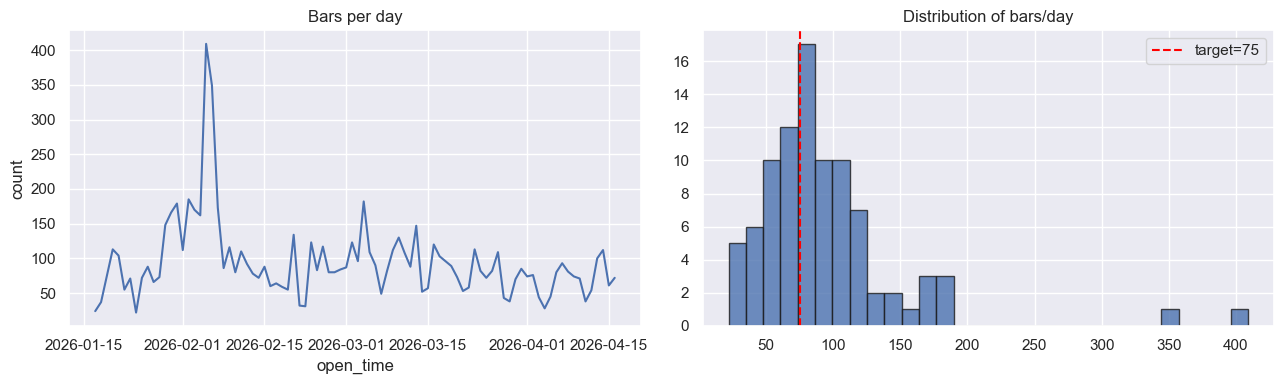

count     90.00000
mean      94.20000
std       57.03226
min       22.00000
25%       64.50000
50%       82.00000
75%      111.50000
max      409.00000


In [11]:
bars_per_day = df.groupby(df["open_time"].dt.date).size()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
bars_per_day.plot(ax=axes[0], title="Bars per day", ylabel="count")
axes[1].hist(bars_per_day, bins=30, edgecolor="k", alpha=0.8)
axes[1].axvline(TARGET_BARS_PER_DAY, color="red", linestyle="--", label=f"target={TARGET_BARS_PER_DAY}")
axes[1].set_title("Distribution of bars/day")
axes[1].legend()
plt.tight_layout()
plt.show()

print(bars_per_day.describe().to_string())

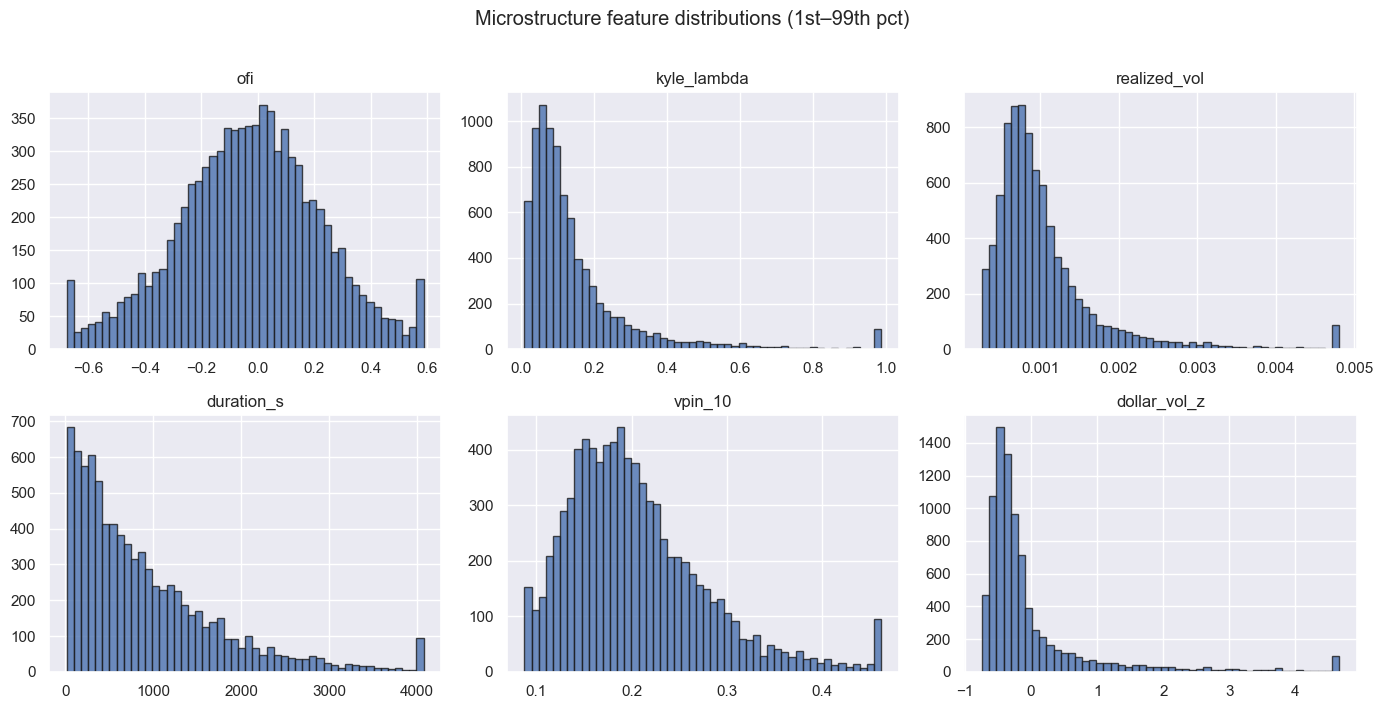

In [12]:
feat_cols = ["ofi", "kyle_lambda", "realized_vol", "duration_s", "vpin_10", "dollar_vol_z"]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flat, feat_cols):
    data = df[col].dropna()
    lo, hi = data.quantile(0.01), data.quantile(0.99)
    data.clip(lo, hi).hist(bins=50, ax=ax, edgecolor="k", alpha=0.8)
    ax.set_title(col)
plt.suptitle("Microstructure feature distributions (1st–99th pct)", y=1.01)
plt.tight_layout()
plt.show()

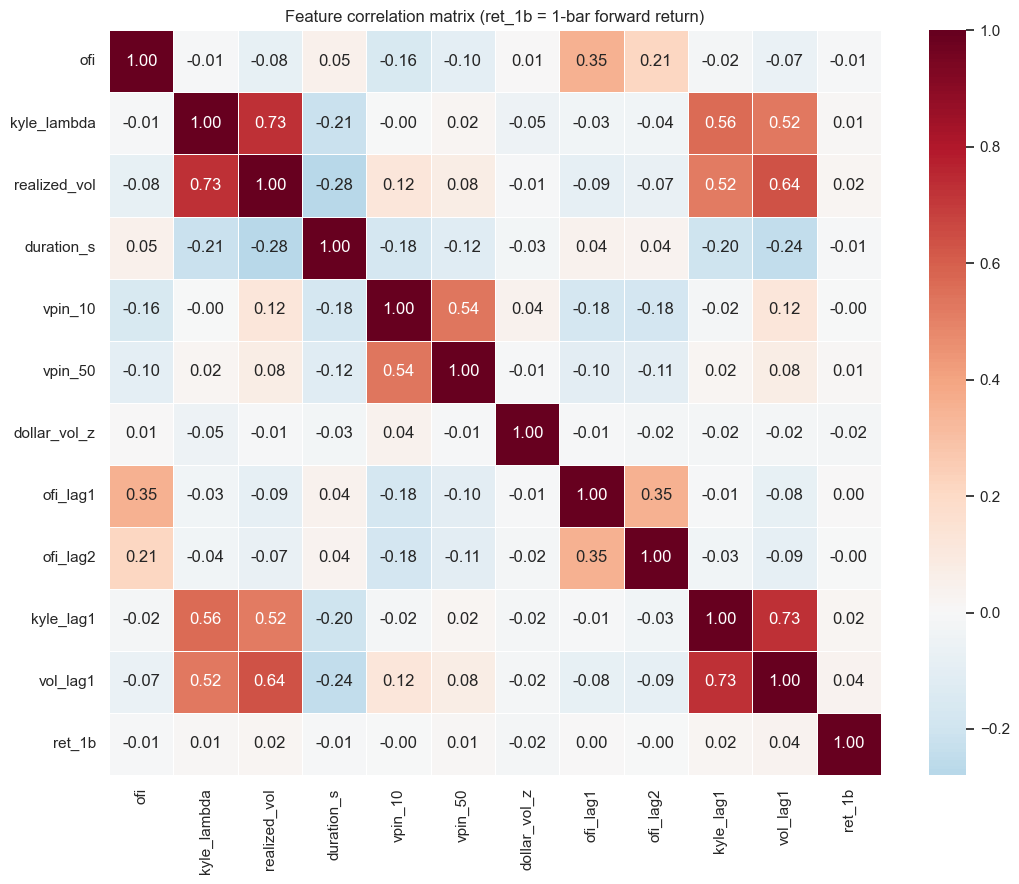

In [13]:
corr_cols = ["ofi", "kyle_lambda", "realized_vol", "duration_s",
             "vpin_10", "vpin_50", "dollar_vol_z",
             "ofi_lag1", "ofi_lag2", "kyle_lag1", "vol_lag1", "ret_1b"]

corr = df[corr_cols].dropna().corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".2f", center=0, cmap="RdBu_r", linewidths=0.4, ax=ax)
ax.set_title("Feature correlation matrix (ret_1b = 1-bar forward return)")
plt.tight_layout()
plt.show()

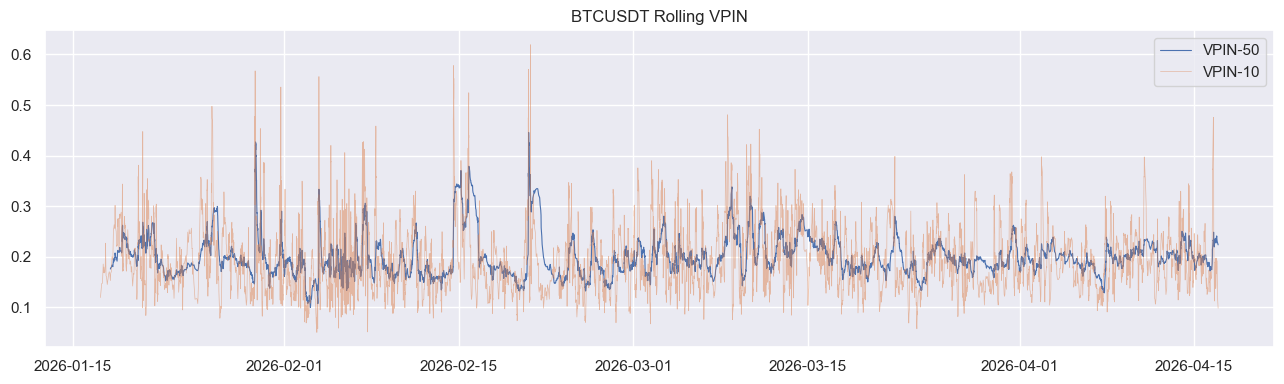

In [14]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(df["open_time"], df["vpin_50"], lw=0.8, label="VPIN-50")
ax.plot(df["open_time"], df["vpin_10"], lw=0.5, alpha=0.5, label="VPIN-10")
ax.set_title(f"{SYMBOL} Rolling VPIN")
ax.legend()
plt.tight_layout()
plt.show()

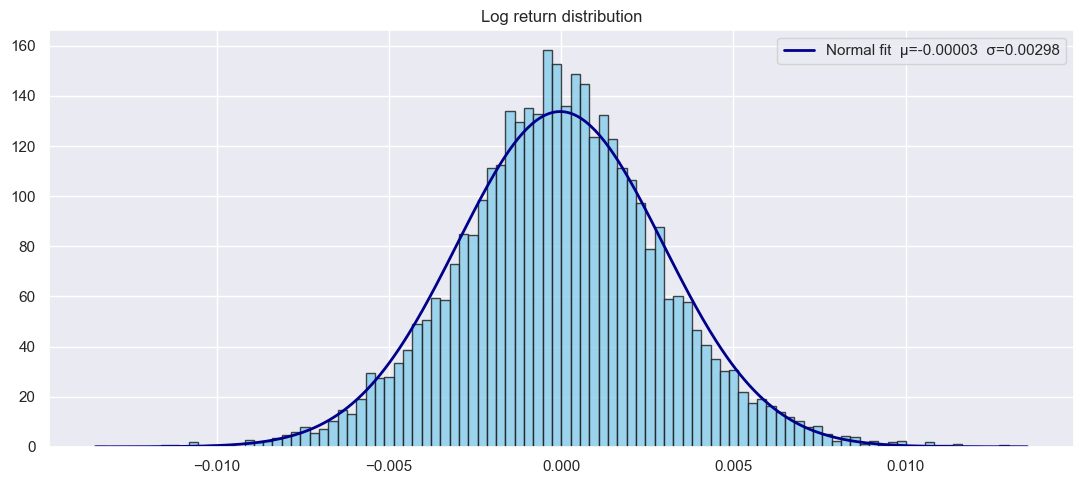

In [15]:
from scipy.stats import norm

data = df["log_return"].dropna()

fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(data, bins=100, color="skyblue", edgecolor="k", alpha=0.8, density=True)

mu, sigma = data.mean(), data.std()
x = np.linspace(data.min(), data.max(), 400)
ax.plot(x, norm.pdf(x, mu, sigma), color="darkblue", lw=2, label=f"Normal fit  μ={mu:.5f}  σ={sigma:.5f}")

ax.set_title("Log return distribution")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
qadf_mat = qadf(np.log(df['close']),
                t = 500,
                p = 0.8)

In [30]:
qadf_mat[:,4]

array([       nan,        nan,        nan, ..., 0.26355544, 0.26335669,
       0.26372484], shape=(8478,))

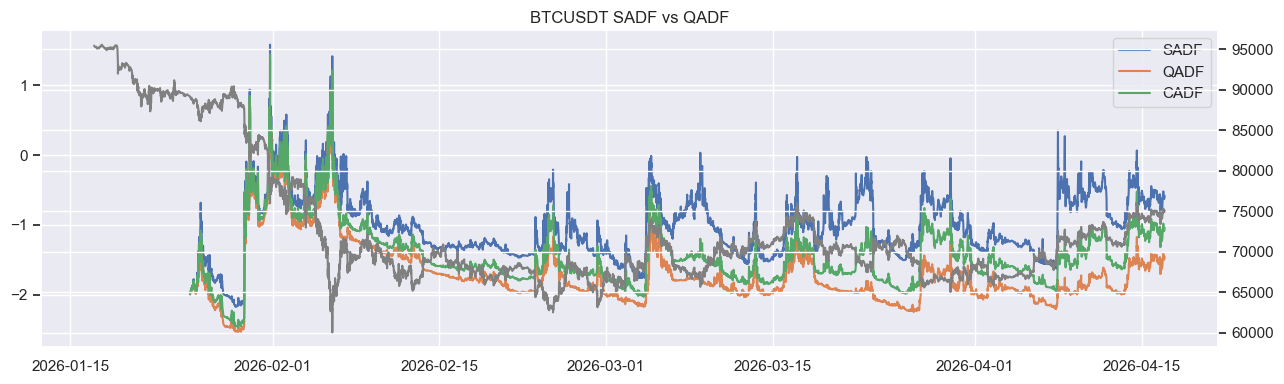

In [34]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(df["open_time"], qadf_mat[:,0], label="SADF")
ax.plot(df["open_time"], qadf_mat[:,1], label="QADF")
ax.plot(df["open_time"], qadf_mat[:,3], label="CADF")
ax.set_title(f"{SYMBOL} SADF vs QADF")
ax.legend()

ax2 = ax.twinx()
ax2.plot(df["open_time"], df["close"], label="Close price", color = 'grey')
plt.tight_layout()
plt.show()